### Dependencies

In [1]:
%pip install imreg_dft

import numpy as np
import os, sys
import matplotlib.pyplot as plt
import csv

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Add current working directory (cwd) to PATH
sys.path.append(os.path.abspath(os.getcwd()))

# Guide to processing drone videos

This quick guide will walk you through processing our drone videos into usable data.

Insert which flight you're currently processing: **SUAS CLASS ONLY**

In [3]:
flight = "flight4" 

## Video directory

This directory should have the video frames (RJPEG files, .jpg) in it. Please avoid changing the filenames of, deleting, or otherwise altering frames in a video without re-running everything in this notebook. I.e., if you change something early in the pipeline, start from the beginning.

In [4]:
# Point to a specific flight
datadir = f"/local/data/imgs589/2251-2255/flights/20251027/high_gain/{flight}"

## Save directory

This directory is where any generated files will get dumped.

Directory is created if it doesn't already exist.

In [5]:
savedir = f"./high_gain_{flight}_save/"
os.makedirs(savedir, exist_ok=True)

## Preprocess Video

### Extract frame-by-frame metadata

This script will go through each frame and extract relevant positional metadata, saving it in a numpy file. If you restart the jupyter kernel after running this, you don't have to run it again because the file will be saved.

In [6]:
from metadata_to_np import metadata_to_np
metadata_to_np(datadir, os.path.join(savedir, "flight_metadata.npy"))

1/123
2/123
3/123
4/123
5/123
6/123
7/123
8/123
9/123
10/123
11/123
12/123
13/123
14/123
15/123
16/123
17/123
18/123
19/123
20/123
21/123
22/123
23/123
24/123
25/123
26/123
27/123
28/123
29/123
30/123
31/123
32/123
33/123
34/123
35/123
36/123
37/123
38/123
39/123
40/123
41/123
42/123
43/123
44/123
45/123
46/123
47/123
48/123
49/123
50/123
51/123
52/123
53/123
54/123
55/123
56/123
57/123
58/123
59/123
60/123
61/123
62/123
63/123
64/123
65/123
66/123
67/123
68/123
69/123
70/123
71/123
72/123
73/123
74/123
75/123
76/123
77/123
78/123
79/123
80/123
81/123
82/123
83/123
84/123
85/123
86/123
87/123
88/123
89/123
90/123
91/123
92/123
93/123
94/123
95/123
96/123
97/123
98/123
99/123
100/123
101/123
102/123
103/123
104/123
105/123
106/123
107/123
108/123
109/123
110/123
111/123
112/123
113/123
114/123
115/123
116/123
117/123
118/123
119/123
120/123
121/123
122/123
123/123


### Load Metadata

Here we load the positional metadata, and we want to find a range of frames to extract data from, and that registration should work well on. Here I select frames where the drone is moving up or down and is not rotated far from the center. For flight #7, it looks like the drone is on the move from frame 0 to frame 80, so I will restrict the processing to those frames. Your research will likely not restrict utilizing these other frames.

Pull metadata

In [7]:
metadata = np.load(os.path.join(savedir, "flight_metadata.npy"))
altitude_abs = metadata[:,0] # Above Sea Level (ASL)
altitude_rel = metadata[:,1] # Above Ground Level (AGL)
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

Plot metadata

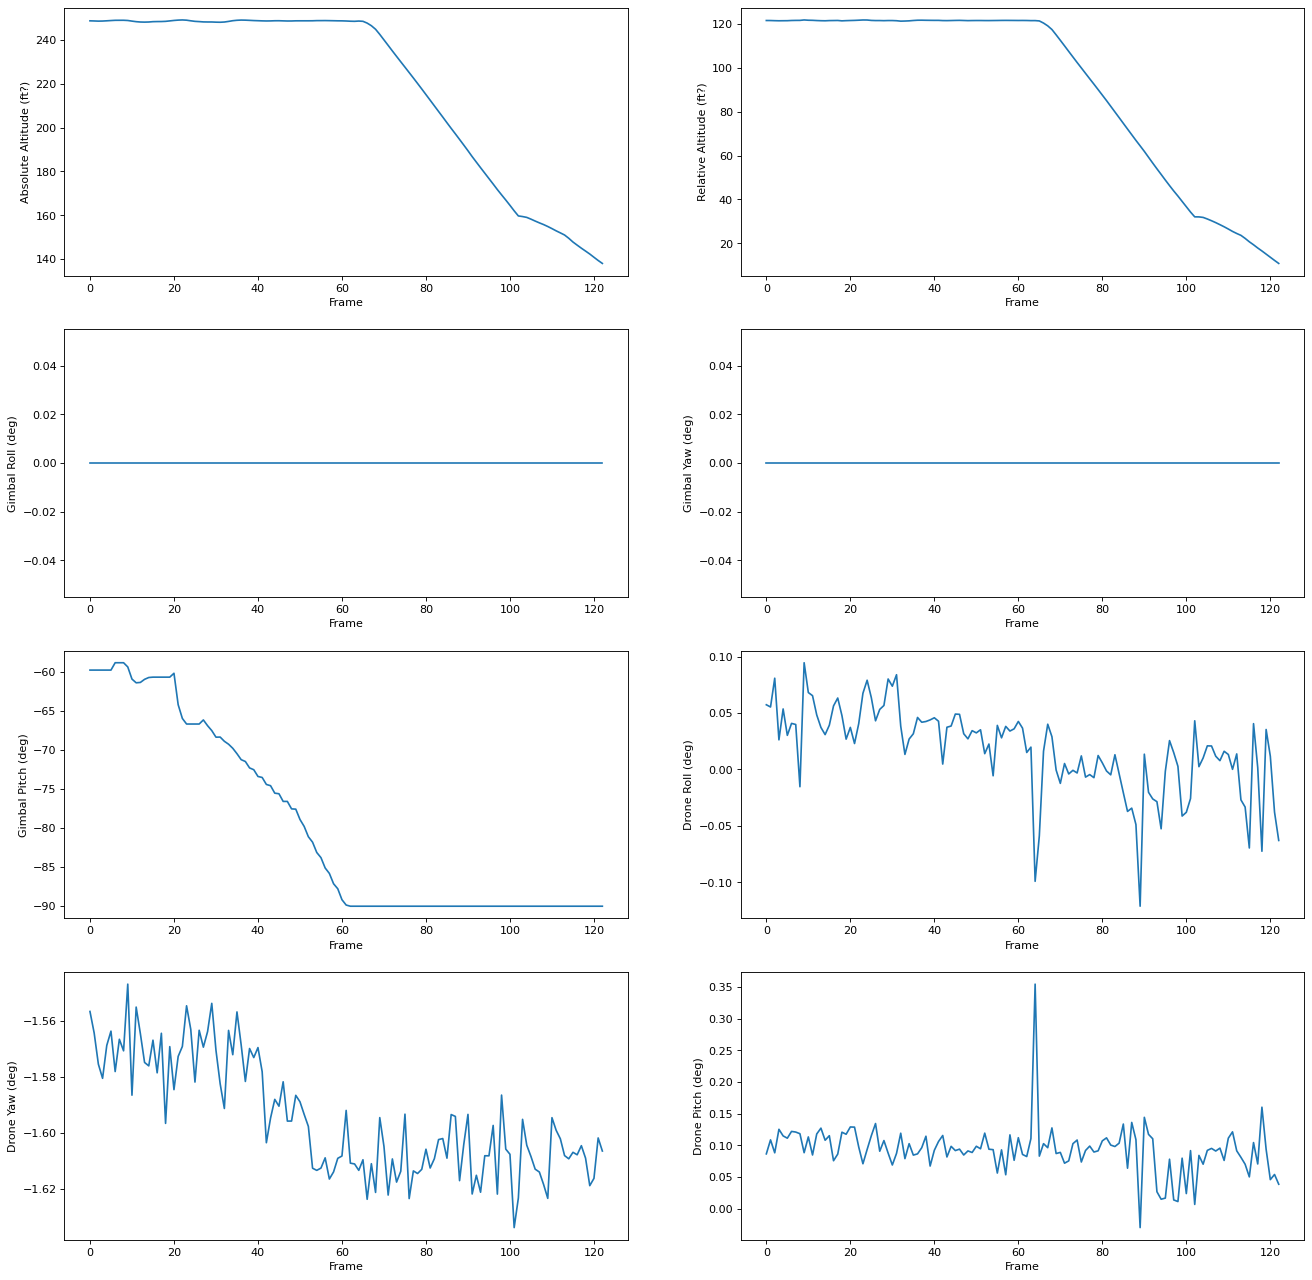

In [8]:
frame_n = np.array(range(len(metadata)), dtype=np.float64)

plt.figure(figsize=(20, 20), dpi=80)

plt.subplot(421)
plt.plot(frame_n, altitude_abs)
plt.xlabel("Frame")
plt.ylabel("Absolute Altitude (ft?)")

plt.subplot(422)
plt.plot(frame_n, altitude_rel)
plt.xlabel("Frame")
plt.ylabel("Relative Altitude (ft?)")

plt.subplot(423)
plt.plot(frame_n, gimbal_roll)
plt.xlabel("Frame")
plt.ylabel("Gimbal Roll (deg)")

plt.subplot(424)
plt.plot(frame_n, gimbal_yaw)
plt.xlabel("Frame")
plt.ylabel("Gimbal Yaw (deg)")

plt.subplot(425)
plt.plot(frame_n, gimbal_pitch)
plt.xlabel("Frame")
plt.ylabel("Gimbal Pitch (deg)")

plt.subplot(426)
plt.plot(frame_n, flight_roll)
plt.xlabel("Frame")
plt.ylabel("Drone Roll (deg)")

plt.subplot(427)
plt.plot(frame_n, flight_yaw)
plt.xlabel("Frame")
plt.ylabel("Drone Yaw (deg)")

plt.subplot(428)
plt.plot(frame_n, flight_pitch)
plt.xlabel("Frame")
plt.ylabel("Drone Pitch (deg)")

plt.show()

In [9]:
# DEBUG - Check potential start_frame
# Range 60-80 particular to flight4
print(f"Values and indices near descending slope\n")
print("Index   |   Value")
print("------------------")
temp = np.empty((20, 2))
temp[:,0] = np.arange(60,80)
temp[:,1] = altitude_abs[60:80]
print(temp)
del temp

Values and indices near descending slope

Index   |   Value
------------------
[[ 60.    248.662]
 [ 61.    248.598]
 [ 62.    248.501]
 [ 63.    248.454]
 [ 64.    248.573]
 [ 65.    248.45 ]
 [ 66.    247.638]
 [ 67.    246.446]
 [ 68.    244.829]
 [ 69.    242.493]
 [ 70.    239.979]
 [ 71.    237.476]
 [ 72.    234.945]
 [ 73.    232.46 ]
 [ 74.    229.993]
 [ 75.    227.547]
 [ 76.    225.087]
 [ 77.    222.62 ]
 [ 78.    220.117]
 [ 79.    217.596]]


### Register Video Frames

Now we need to register the video frames. This function runs by sorting the frames descending in terms of altitude, and then registering frames to a "reference" frame. The first reference frame is the first frame of the video, and the subsequent reference frames are every Nth frame. But this is just the default, different strategies for selecting reference frames can be chosen (by programming them yourself 🙂). Setting `ref_every=1` will make it so that every frame has the previous frame as its reference, but this would cause more drift. `ref_every=5` to `ref_every=10` are good picks.

Every time a frame is registered, the function spits out a "Success" metric. This is from the registration library I used (`imreg_dft`), and it doesn't have all that much actual meaning. But if it's really low it might be a good way to filter out obviously bad registrations.

### Set video frame crop regions. 
- Look at "Absolute Altitute" plot from above (top left)
- Find region of descent
- Set `start_frame` to $beginning$ of descent
- Set `end_frame` to $end$ of descent

In [10]:
start_frame = 65
end_frame = len(frame_n)

### Registers frames of cropped video region
- Notice if the cell below outputs:
```bash
URGENT WARNING: There was a bad frame used as a reference, adjust registration strategy.
New reference frame: ...
```
- You'll have to change the `ref_every` variable.
- To change `ref_every`, defer to markdown cell "$Register Video Frames$" 

In [11]:
from register_video import register_video
register_video(
    datadir=datadir,
    outpath=os.path.join(savedir, "flight_registration.npz"),
    metadatapath=os.path.join(savedir, "flight_metadata.npy"),
    start_frame=start_frame,
    end_frame=end_frame,
    ref_every=5
)

# NOTE: Will be re-written by Joe in the future to handle off-axis (affine dir)

1/58, Success=0.6648456304039922
2/58, Success=0.5610438493639689
3/58, Success=0.441270723323252
4/58, Success=0.47697686094871095
5/58, Success=0.42776652837384793
New reference frame: 5
6/58, Success=0.7527861777627175
7/58, Success=0.6103951180782893
8/58, Success=0.5393156185704004
9/58, Success=0.49781285254050733
10/58, Success=0.46223912825067687
New reference frame: 10
11/58, Success=0.807951314482054
12/58, Success=0.6239240830404695
13/58, Success=0.5876997579195362
14/58, Success=0.4707669568301157
15/58, Success=0.4631055096209084
New reference frame: 15
16/58, Success=0.8071477043169011
17/58, Success=0.6765455223448805
18/58, Success=0.551542381866634
19/58, Success=0.5276286342113808
20/58, Success=0.417054006503897
New reference frame: 20
21/58, Success=0.6533869667912855
22/58, Success=0.48747042028460064
23/58, Success=0.47397028356399623
24/58, Success=0.41512799886394336
25/58, Success=0.3935562671824824
New reference frame: 25
26/58, Success=0.5551718853704007
27/

## Use the ROI drawing tool

Now that these files are present, you can use the ROI drawing tool to draw your ROIs. The ROIs in frames with "is reference: True" get copied, so focus on editing these ones to get accurate ROIs. 
- Note: The tool may not work if you don't do all the ROIs at once in order. 
- Note: You need to input digital count to radiance calibration linear coefficients with the comment under "\#Coefficients file"

In [41]:
import subprocess
subprocess.run([ # Input args:
    # Program language i.e. Python
    "python",
    # Joe's Python script to run
    "rois_video.py",
    # Input data directory
    datadir,
    # Output data directory
    savedir,
    # Flight metadata file
    os.path.join(savedir, "flight_metadata.npy"),
    # Flight registration file
    os.path.join(savedir, "flight_registration.npz"),
    # Calibration coefficients file 
    # Match the calibration file temp to ambient temp during flight
    "/home/cjw9009/Desktop/suas_scripts/20251206_1200_10ec_10_70x5_manual_coefficients.npy",
    # Label for start frame
    str(start_frame),
    # Label for end frame
    str(end_frame)
])

CompletedProcess(args=['python', 'rois_video.py', '/local/data/imgs589/2251-2255/flights/20251027/high_gain/flight4', './high_gain_flight4_save/', './high_gain_flight4_save/flight_metadata.npy', './high_gain_flight4_save/flight_registration.npz', '/home/cjw9009/Desktop/suas_scripts/20251206_1200_10ec_10_70x5_manual_coefficients.npy', '65', '123'], returncode=0)

## Load data

Here it is key to make sure that the start and end frames are the same. The frame number in the csv file generated by the ROI tool corresponds to the index of the frame when sorted by altitude, so that must be done first. This is janky, and can/should be changed in the future so that the csv data is associated with the actual filenames.

In [13]:
# Load metadata for video
metadata = np.load(os.path.join(savedir, "flight_metadata.npy"))
metadata = metadata[start_frame:end_frame+1]
altitude_abs = metadata[:,0]
altitude_rel = metadata[:,1]
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

sort_idxs = (-altitude_abs).argsort() # Sort descending (literally)
metadata = metadata[sort_idxs]

altitude_abs = metadata[:,0]
altitude_rel = metadata[:,1]
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

# Load ROI stats from CSV file
roi_stats = {}
datatypes = {
    "frame": int,
    "instance": int,
    "mean": float,
    "stdev": float
}

# Save ROI stats to CSV
with open(os.path.join(savedir, "roi_stats.csv"), newline='') as csvfile:
    # Reader object
    csvreader = csv.reader(csvfile, delimiter=',')
    header = next(csvreader)
    
    # Extract values from CSV into roi_stats
    for row in csvreader:
        for column, value in enumerate(row):
            roi_stats.setdefault(header[column], []).append(datatypes[header[column]](value))
            
# Put ROI stats to globally accessible variables
roimean = roistdev = roiinstance = roiframe = None # global variables
for key, datatype in datatypes.items():
    # This creates the variables:
    # - 'roiframe'
    # - 'roiinstance' 
    # - 'roimean'
    # - 'roistdev'
    globals()["roi"+key] = np.array(roi_stats[key], dtype=datatype)

## Plotting data

Here the instance ID is plotted as the color (using the categorical colormap Set3).

Extract ROI statistics

Plot **Mean**

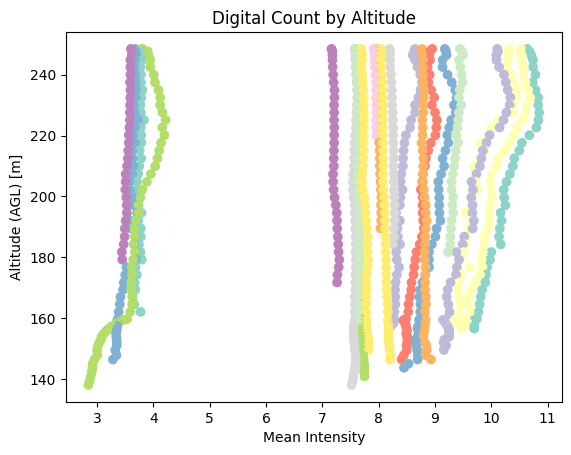

In [14]:
plt.scatter(roimean, altitude_abs[roiframe], c=roiinstance, cmap="Set3")
plt.title("Digital Count by Altitude")
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.show()

Plot **Standard Deviation**

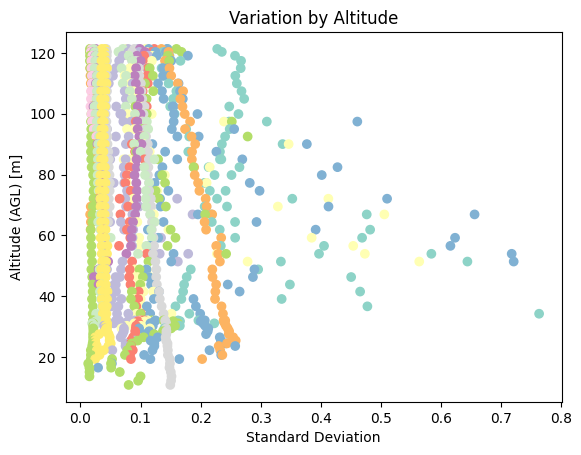

In [15]:
plt.scatter(roistdev, altitude_rel[roiframe], c=roiinstance, cmap="Set3")
plt.title("Variation by Altitude")
plt.xlabel("Standard Deviation")
plt.ylabel("Altitude (AGL) [m]")
plt.show()

Plot **ROI Instance**

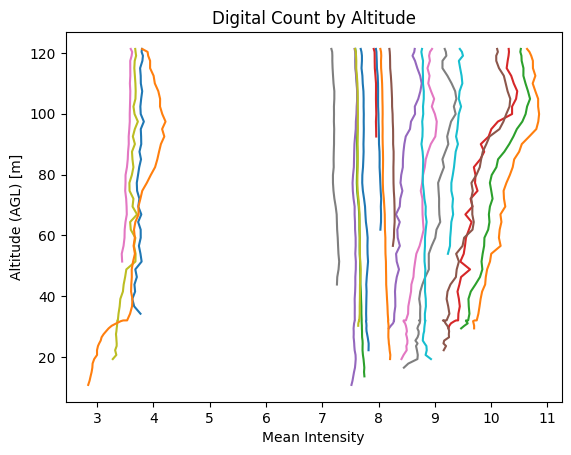

In [16]:
plt.figure()
for instance in np.unique(roiinstance):
    plt.plot(roimean[roiinstance==instance], altitude_rel[roiframe][roiinstance==instance])
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude")
plt.show()

Plot **Mean w/ Error Bars**

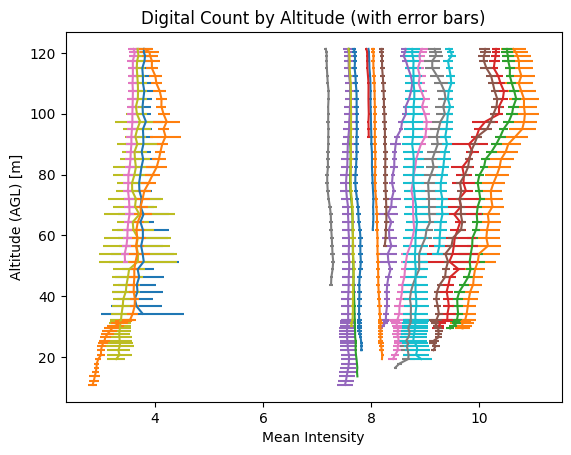

In [17]:
plt.figure()
for instance in np.unique(roiinstance):
    plt.errorbar(roimean[roiinstance==instance], altitude_rel[roiframe][roiinstance==instance], xerr=roistdev[roiinstance==instance])
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude (with error bars)")
plt.show()

Plot **Mean w/ Violin Plot**

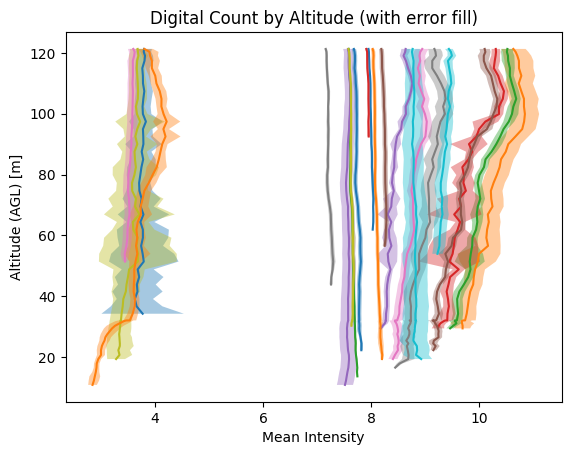

In [18]:
plt.figure()
for instance in np.unique(roiinstance):
    x = roimean[roiinstance==instance]
    y = altitude_rel[roiframe][roiinstance==instance]
    err = roistdev[roiinstance==instance]
    plt.plot(x, y)
    plt.fill_betweenx(y, x-err, x+err, alpha=0.4)
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude (with error fill)")
plt.show()

### Curve Interpolation

Fit regression curve

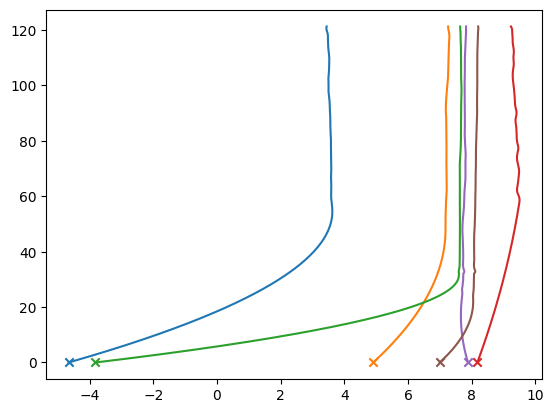

In [19]:
# regress to ground radiance
from scipy.interpolate import UnivariateSpline

plt.figure()

pink_regions = [16, 17, 18, 19, 20, 21]
ground_leaving_radiances = []
altitude_radiances = []

for instance in np.unique(roiinstance):

    # flip the x and y axis for interpolation purposes
    means = roimean[roiinstance==instance]
    altitudes = altitude_rel[roiframe][roiinstance==instance]

    # if means in nan, cut the vectors to only the non-nan values
    valid_idxs = ~np.isnan(means)
    means = means[valid_idxs]
    altitudes = altitudes[valid_idxs]
    # sort by altitudes increasing
    altitudes = altitudes[np.argsort(altitudes)]
    means = means[np.argsort(altitudes)]

    # k=1 linear, k=2 quadratic, k=3 cubic (default), k=4, k=5 (max)
    spline = UnivariateSpline(altitudes, means, k=2, s=0)  # s=0 = interpolating, higher s is smoothing
    ground_radiance = spline(0)

    x_fine = np.linspace(0, altitudes.max(), 500)
    

    # append ground leaving radiance and altitude radiance for pink regions for upwelling and transmission calculations
    if instance in pink_regions:
        plt.plot(spline(x_fine), x_fine)
        plt.scatter(ground_radiance, 0, zorder=5, marker='x')

        ground_leaving_radiances.append(ground_radiance)
        altitude_radiances.append(means[-1]) # last mean is highest altitude radiance value

Plot regression curve

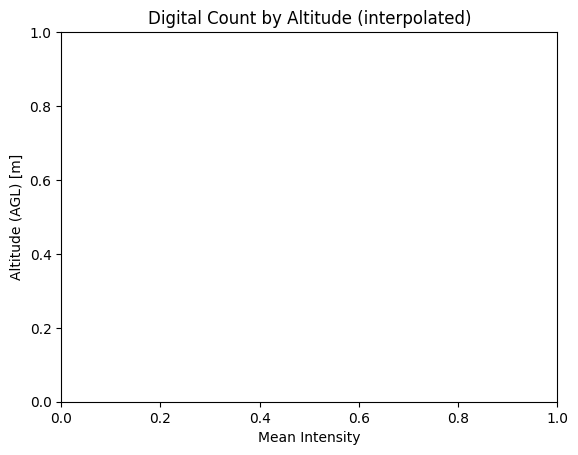

In [20]:
plt.ylabel("Altitude (AGL) [m]")
plt.xlabel("Mean Intensity")
plt.title("Digital Count by Altitude (interpolated)")
plt.show()

Calculate upwelling transmission values for region

Text(0, 0.5, 'Radiance at Altitude')

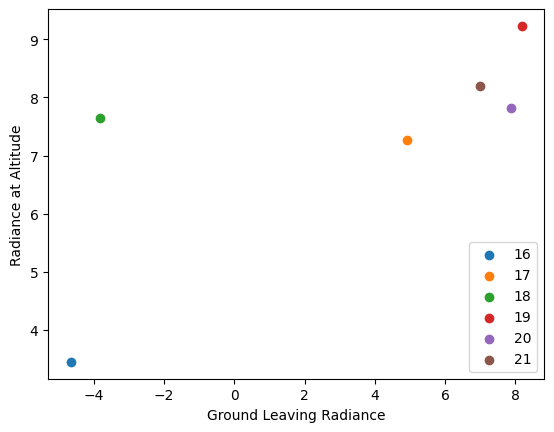

In [21]:
# Transmission values for pink regions
plt.figure()

for i in range(len(pink_regions)):
    plt.scatter(ground_leaving_radiances[i], altitude_radiances[i], label=f"Region {pink_regions[i]}")
    
plt.legend(pink_regions, loc="best")
plt.xlabel("Ground Leaving Radiance")
plt.ylabel("Radiance at Altitude")